In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import scipy as sp
import seaborn as sns
import pandas as pd
from tqdm import tqdm

In [2]:
# Left = 0, Right = 1

# def sigmoid(x, a=1.0, b=0.0):
#     #! add threshold for numerical stability if needed
#     return 1/(1+np.exp(-a*(x-b)))

def sigmoid(x, w=1.0, b=0.0, g=1.0):
    return 1/(1+np.exp(-g*(w*x + b)))

def eps(y):
    if float(y)==0.:
        return -1.
    elif float(y)==1:
        return 1.
    else:
        raise ValueError('y must be 0 or 1')

def reward(x, y):
    if (x < 0 and y == 0) or (x > 0 and y == 1):
        r = 1.
    else:
        r = 0.
    return r

def policy_gradient(w, x):
    p_R = sigmoid(w*x)
    p_L = 1 - p_R 
    effective_reward = np.sum([
        eps(y) * reward(x, y) for y in [0,1]
    ])
    return effective_reward * p_R * p_L * x

<Axes: >

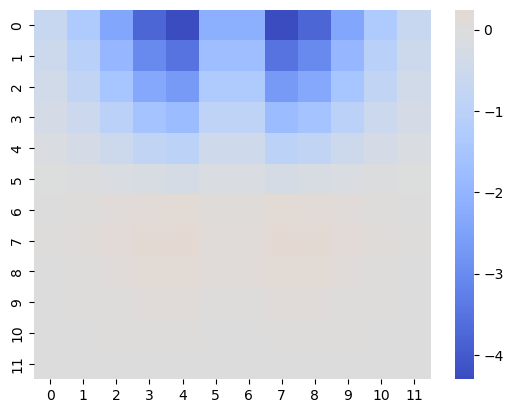

In [3]:
x_range = np.linspace(-1,1,12)

w1 = 5.0
w2 = lambda x: w1 + policy_gradient(w1, x)

Z = []
for _x in x_range:
    change = sigmoid(w2(_x) * x_range) - sigmoid(w1 * x_range)
    percent_change = np.divide(change, sigmoid(w1 * x_range)) * 100
    Z.append(list(percent_change))

Z = np.array(Z)
sns.heatmap(Z.T, center=0., cmap='coolwarm')

## Vectorize

Rewrite the above with $w \in \mathbb{R}^2$ and the augmented stimulus $\boldsymbol{x} = [1, x]$

In [4]:
def vec(x):
    return np.array([1,x])
def unvec(x):
    return x[1]

def policy_gradient_vectorized(vw, vx):
    p_R = sigmoid(eps(1.0) * np.dot(vw, vx))
    p_L = 1 - p_R 

    x = unvec(vx)
    effective_reward = np.sum([
        eps(y) * reward(x, y) for y in [0,1]
    ])
    return effective_reward * p_R * p_L * np.array(vx)



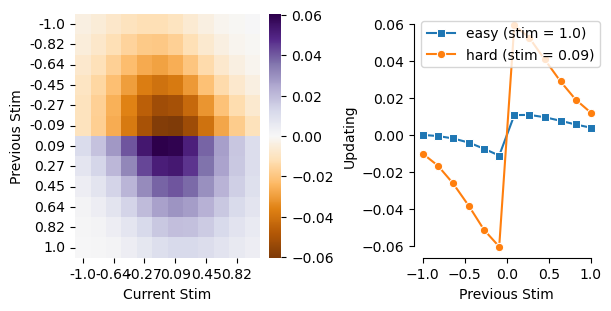

In [5]:
from matplotlib.ticker import FormatStrFormatter

vx_range = np.array([vec(x) for x in x_range])

vw_prev = [0,3] # average (mean, without noise) of previous 

average_psychometric =1.# sigmoid(vw_prev @ vec(0.0))

Z = []
for prev_vx in vx_range:
    for vx in vx_range:
        vw_new = vw_prev + policy_gradient_vectorized(vw_prev, prev_vx)
        change = sigmoid(vw_new @ vx) - sigmoid(vw_prev @ vx)
        # percent_change = np.divide(change, average_psychometric) * 100
        # Z.append(list(percent_change))
        entry = {
            'Previous Stim': round(unvec(prev_vx), 2),
            'Current Stim': round(unvec(vx),2), 
            'Updating': change
            }
        Z.append(entry)


# Z = np.array(Z).T
fig, axs = plt.subplots(ncols=2, figsize=[6,3], constrained_layout=True)
Z = pd.DataFrame(Z, columns=['Previous Stim', 'Current Stim', 'Updating'])
Z_matrix = Z.pivot(columns='Previous Stim', index='Current Stim', values='Updating')
sns.heatmap(Z_matrix.T, center=0., cmap='PuOr', ax=axs[0]);

sns.lineplot(x='Previous Stim', y='Updating', data=Z.query("`Current Stim`==1.0"), 
            label='easy (stim = 1.0)', ax=axs[1], marker='s')
sns.lineplot(x='Previous Stim', y='Updating', data=Z.query("`Current Stim`==0.09"), 
            label='hard (stim = 0.09)', ax=axs[1], marker='o')

axs[1].legend(loc=2)
sns.despine(ax=axs[1], trim=True)
plt.savefig('output.pdf', format='pdf')


# Policy

In [6]:
def cumulative_gaussian(x, sigma=1.0, mu=0.0):
    return 0.5*(1+sp.special.erf((x-mu)/(sigma*np.sqrt(2))))

def Phi(x):
    return cumulative_gaussian(x)

def average_by_category(X, Y, return_std=False):
    X = np.asarray(X)
    Y = np.asarray(Y)
    unique_categories = np.unique(X)
    averages = []
    stds = []

    for category in unique_categories:
        mask = (X == category)
        average_value = np.mean(Y[mask])
        averages.append(average_value)

        std_value = np.std(Y[mask])
        stds.append(std_value)

    if return_std:
        return unique_categories, np.array(averages), np.array(stds)
    else:
        return unique_categories, np.array(averages)

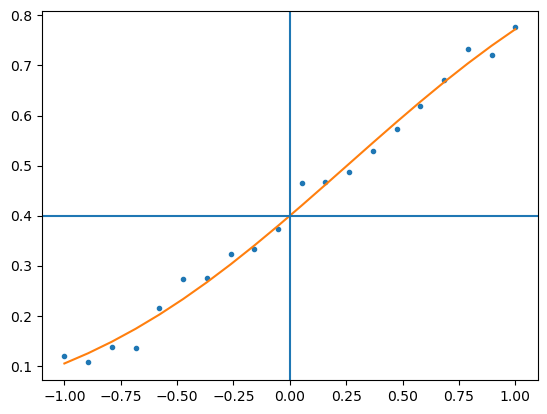

In [7]:
## Start with the max + belief policy

x_range = np.linspace(-1,1,20)
sigma = 1.0

V_R = 0.2
V_L = 0.3

x_samples = []
choice_samples = []
for _ in range(10000):
    true_x = np.random.choice(x_range)
    x_hat = true_x + sigma * np.random.randn()

    p_R = cumulative_gaussian(x_hat)
    p_L = 1-p_R

    Qs = [p_L*V_L, p_R*V_R]

    choice = np.argmax(Qs)
    # choice = np.random.binomial(n=1, p=sp.special.softmax(Qs)[1])

    x_samples.append(true_x)
    choice_samples.append(choice)

X, Y = average_by_category(np.array(x_samples), np.array(choice_samples))
a = np.sqrt(2) * sp.special.erfinv((V_L-V_R)/(V_R+V_L))

fig, ax = plt.subplots();
ax.plot(X, Y, '.');
ax.plot(X, cumulative_gaussian(X, sigma=sigma, mu=a))
# ax.plot(X, [tilde_p_R(x, V_L=V_L, V_R=V_R, sigma=sigma) for x in X])
ax.axhline(y=V_R/((V_R+V_L)))
ax.axvline(x=0.)

In [8]:
def tilde_p_R(x, V_R=1.0, V_L=1.0, sigma=1.0):
    '''
    returns p_R(x) = simgoid(tilde_w[0]* x + tilde_w[1])
    where
    tilde_w = [(V_R + V_L)/(2*sigma*sqrt(pi)), (V_L-V_R)/2]
    '''
    tilde_w = 0.5*np.array([ V_R-V_L, (V_R+V_L)/(0.5*sigma*np.sqrt(np.pi))])
    wx = np.dot(tilde_w, vec(x))
    p_R = sigmoid(wx)
    return p_R

In [9]:
popt, pcov, info_dict, _, _ = sp.optimize.curve_fit(cumulative_gaussian, X, Y, full_output=True)
print(popt)
print(np.sum(info_dict['fvec']))

[1.00916185 0.24966066]
0.008991826574046832


In [10]:
vec(0.5)

array([1. , 0.5])

# Approximating the model with a sigmoid

In [11]:
# def cumulative_gaussian(x, mu=0.0, sigma=1.0):
#     return 0.5 * (1 + sp.special.erf((x-mu)/(sigma * np.sqrt(2))))

# def sigmoid(x, w=1.0, b=0.0, g=1.0):
#     return 1/(1+np.exp(-g*(w*x + b)))

# def average_by_category(X, Y, return_std=False):
#     X = np.asarray(X)
#     Y = np.asarray(Y)
#     unique_categories = np.unique(X)
#     averages = []
#     stds = []

#     for category in unique_categories:
#         mask = (X == category)
#         average_value = np.mean(Y[mask])
#         averages.append(average_value)

#         std_value = np.std(Y[mask])
#         stds.append(std_value)

#     if return_std:
#         return unique_categories, np.array(averages), np.array(stds)
#     else:
#         return unique_categories, np.array(averages)

In [12]:
def true(x, V_R, V_L, sigma):
    a = sigma * np.sqrt(2) * sp.special.erfinv((V_L - V_R)/(V_R + V_L))
    return cumulative_gaussian(x, mu=a, sigma=sigma)

def approx(x, V_R, V_L, sigma):
    return sigmoid(x, w=1/sigma, b=(np.sqrt(np.pi/2) * (V_R - V_L)/(V_R + V_L)), g=3/np.sqrt(np.pi))

def MSE(X, Y):
    return np.mean(np.square(X - Y))

0


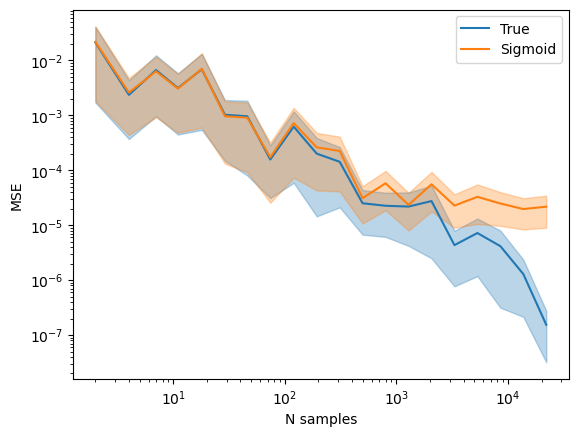

In [13]:
x_range = np.linspace(-1,1,20)

sigma = 0.2
V_R = 0.7
V_L = 1.0

n_samples_list = np.exp(np.linspace(1,10,20)).astype(int)

X = []
Y_true = []
Y_approx = []
for i in range(1):
    print(i)
    for n_samples in n_samples_list:
        _X = []
        _Y = []
        for x in x_range:
            for _ in range(n_samples):
                # x = np.random.uniform(-1,1)
                x_hat = x + sigma * np.random.randn()
                p_R = cumulative_gaussian(x_hat, sigma=sigma)
                p_L = 1 - p_R

                choice = np.argmax([p_L*V_L, p_R*V_R])
                _Y.append(choice)
                _X.append(x)

            x_plot, choices = average_by_category(_X, _Y)

            X.append(n_samples)
            Y_true.append(MSE(choices, true(x_plot, V_R, V_L, sigma)))
            Y_approx.append(MSE(choices, approx(x_plot, V_R, V_L, sigma)))

_x1, MSEs_true, MSEs_std_true = average_by_category(X, Y_true, return_std=True)
_x2, MSEs_approx, MSEs_std_approx = average_by_category(X, Y_approx, return_std=True)

fig, ax = plt.subplots()
ax.plot(_x1, MSEs_true, c='tab:blue', label='True')
ax.fill_between(_x1, MSEs_true-MSEs_std_true, MSEs_true+MSEs_std_true, alpha=0.3, color='tab:blue')
ax.plot(_x2, MSEs_approx, c='tab:orange', label='Sigmoid')
ax.fill_between(_x2, MSEs_approx-MSEs_std_approx, MSEs_approx+MSEs_std_approx, alpha=0.3, color='tab:orange')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('N samples')
ax.set_ylabel('MSE')
ax.legend()
# plt.savefig('model_MSE_comparison.pdf', format='pdf', dpi=300)

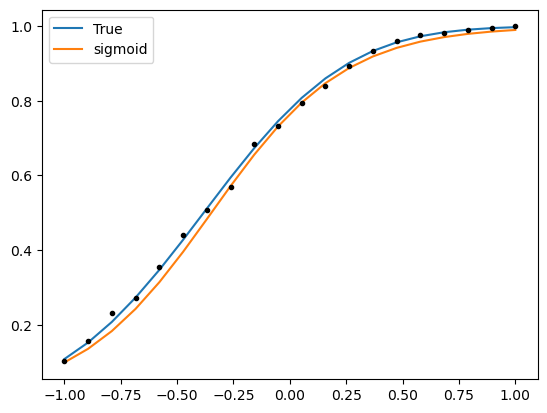

In [14]:
sigma = 0.5
V_R = 0.7
V_L = 0.2

X = []
Y = []
for x in x_range:
    for _ in range(1000):
        x_hat = x + sigma * np.random.randn()
        p_R = cumulative_gaussian(x_hat, sigma=sigma)
        p_L = 1 - p_R

        choice = np.argmax([p_L*V_L, p_R*V_R])
        Y.append(choice)
        X.append(x)

a = sigma * np.sqrt(2) * sp.special.erfinv((V_L - V_R)/(V_R + V_L))
x_plot, choices = average_by_category(X, Y)

fig, ax = plt.subplots()
ax.plot(x_plot, choices, '.', c='k');
ax.plot(x_plot, true(x_plot, V_R, V_L, sigma), label='True', zorder=-1);
ax.plot(x_plot, approx(x_plot, V_R, V_L, sigma), label='sigmoid', zorder=-1);
ax.legend();

### Expected P_R 

In [15]:
def lapse_cumulative_gaussian(x, lam, mu, sigma):
    return lam + (1-2*lam)*cumulative_gaussian(x, mu=mu, sigma=sigma)

In [16]:
from scipy.stats import multivariate_normal

def estimate(x, a, sigma):
    # return 0.5*(1-np.square(cumulative_gaussian(a, mu=x, sigma=sigma)))
    # return 0.5*(1-cumulative_gaussian(a, mu=0, sigma=sigma)*cumulative_gaussian(a, mu=x, sigma=sigma))
    return cumulative_gaussian(a, mu=0, sigma=sigma) - cumulative_gaussian(a, mu=0, sigma=sigma)

def estimate2(x, a, sigma):
    t1 = 1/sigma * cumulative_gaussian(x, mu=0, sigma=sigma*np.sqrt(2)) * (1-cumulative_gaussian(a, mu=0, sigma=sigma))
    t2 = cumulative_gaussian(x, mu=0, sigma=sigma*np.sqrt(2)) * (1-cumulative_gaussian(x, mu=-a, sigma=sigma))
    return t1 - t2

def estimate3(x, a, sigma):
    return 1 - cumulative_gaussian(a, mu=0, sigma=sigma)*cumulative_gaussian(a, mu=0, sigma=sigma)*cumulative_gaussian(a, mu=x, sigma=sigma)

def estimate4(x, a, sigma):
    mean = np.array([-x,-x])
    cov = np.array([[2*sigma**2, sigma**2],[sigma**2,sigma**2]])
    # return 1/sigma *cumulative_gaussian(x=x, mu=0, sigma=np.sqrt(sigma**2+1)) 
    return multivariate_normal.cdf(x=[0,-a], mean=mean, cov=cov)

A, B, C, sigma [3.80530005 0.50871239]


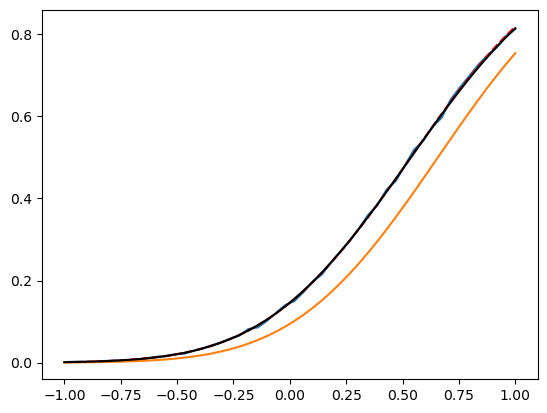

In [17]:
def func(x, sigma, mu):
    return cumulative_gaussian(x, sigma=sigma, mu=mu)# + (1-a)
def func2(x, a, w, b):
    return a*sigmoid(x, w=w, b=b) + (1-a)
def func3(x, a, b):
    return (-a*estimate(x, a=0, sigma=sigma) + b)/(1-a)
def softplus(x, a=1.0, b=0.0, c=0.0):
    threshold = 20
    aff = a*x-b
    if aff > threshold:
        return (1/a)*aff+c
    elif aff < - threshold:
        return c
    else:
        return (1/a)*np.log(1+np.exp(aff)) + c
def func4(x, A, sigma):
    # mu = D*np.log(1+np.exp(A*(transition_point-B))) + C
    mu = softplus(transition_point, A)
    return cumulative_gaussian(x, sigma=sigma, mu=mu)
def estimate5(x, a, sigma,):
    mu = sigma*(softplus(a/sigma))
    return cumulative_gaussian(x, sigma=sigma, mu=mu)

sigmas = np.linspace(0.1,3,20)
transition_point = 0.5 # a
N_MC_samples = 10000
x_range = np.linspace(-1.0,1.0,50)
popts = []
popts_mu = []
sigma = 0.5
# for sigma in sigmas:
integral_values = []
for x in x_range:
    p_Rs = []
    for _ in range(N_MC_samples):
        x_hat = x + sigma*np.random.randn()
        indicator = 1 if x_hat > transition_point else 0
        # if x_hat < 0:
        #     # p_Rs.append(np.nan)
        #     continue
        # else:
        p_R = cumulative_gaussian(x_hat, mu=0, sigma=sigma)
        p_Rs.append(indicator*p_R)
    integral_values.append(np.mean(p_Rs))


popt, pcov = sp.optimize.curve_fit(func4, x_range, integral_values)
print('A, B, C, sigma', popt)
# popts_mu.append(popt[1])

# popts_mu = np.array(popts_mu)
def affine(x, a, b):
    return a*x + b

# popt2, _ = sp.optimize.curve_fit(affine, sigmas, popts)
# print(popt2)

# popt3, _ = sp.optimize.curve_fit(softplus, sigmas, popts_mu)
# print(popt3)

# fig, ax = plt.subplots()
# ax.plot(sigmas, popts, '.');
# ax.plot(sigmas, popts_mu, '.');
# # ax.plot(sigmas[sigmas>transition_point], affine(sigmas[sigmas>transition_point], *popt3), c='g');
# ax.plot(sigmas, softplus(sigmas, *popt3), c='g');
# ax.plot(sigmas, affine(sigmas, *popt2), c='r');
# # ax.set_xscale('log')
# # # popt3, pcov3 = sp.optimize.curve_fit(func3, x_range, integral_values)
# # # print(popt3, np.diag(pcov3))

fig, ax = plt.subplots();
ax.plot(x_range, integral_values)
# ax.axhline(y=0.5)
# ax.axhline(y=1.0)
ax.plot(x_range, func4(x_range, *popt), c='r', ls='--')
ax.plot(x_range, estimate5(x_range, a=transition_point, sigma=sigma))
# ax.plot(x_range, func3(x_range, *popt3), c='g', ls='--')
ax.plot(x_range, [estimate4(x, a=transition_point, sigma=sigma) for x in x_range], c='k')
# ax.plot(x_range, np.array([estimate4(x, a=0, sigma=sigma) for x in x_range]), c='k')
# plt.plot(x_range, cumulative_gaussian(x_range, sigma=sigma*np.sqrt(2)), c='g', ls='--')


# Inference

In [18]:
x_range = np.linspace(-1,1,20)
def update_values(V_L, V_R, x, y, x_hat, alpha, sigma):
    assert float(y) in [0., 1.]
    if y==1:
        V_R = V_R + alpha*(reward(x,y) - Phi(x/sigma)*V_R)
    else:
        V_L = V_L + alpha*(reward(x,y) - Phi(-x/sigma)*V_L)
    return [V_L, V_R]

def decision(x_hat, V, sigma, softmax=False):
    if softmax:
        V_L, V_R = V
        p_R = Phi(x_hat/sigma)
        p_L = 1 - p_R
        p = sp.special.softmax([p_L*V_L, p_R*V_R])[1]
        return np.random.binomial(1, p=p)
    else:
        a = transition_point(V, sigma=sigma)
        return float(x_hat > a)

def simulate(T, alpha, sigma, softmax=False):
    V = [0.2, 0.2]
    X_indices = np.random.choice(len(x_range), size=T, replace=True)
    X = np.array([x_range[i] for i in X_indices])
    X_hat = X + sigma * np.random.randn(T)

    Y, Vs = [], []
    for t in range(T):
        y = decision(X_hat[t], V, sigma=sigma, softmax=softmax)

        Vs.append(V)
        Y.append(y)

        V = update_values(*V, x=X[t], y=Y[t], x_hat=X_hat[t], alpha=alpha, sigma=sigma)
    return X, Y, X_hat, Vs

In [18]:
def MAP_estimate(X, Y, alpha, sigma, n_iter=10):
    # Initialize loop
    X_hat = X #np.zeros_like(X)
    
    X_hats = [X_hat]
    for _ in range(n_iter):
        # Given current estimate of X_hat, compute estimate of values V
        V = compute_estimated_values(X, Y, X_hat, alpha, sigma)

        # Given values, estimate new value of X_hat
        X_hat = MAP(X, Y, V, alpha, sigma).flatten()
        X_hats.append(X_hat)

    return X_hats, V
    
def MAP_estimate_loop(X, Y, alpha, sigma):
    T = len(Y)
    V = [0.2, 0.2]
    x_hat = MAP_xi(X[0], Y[0], V, sigma)
    
    X_hat = np.zeros(T)
    X_hat[0] = x_hat
    for t in range(1,T):
        V = update_values(V[0], V[1], X[t-1], Y[t-1], X_hat[t-1], alpha, sigma)
        X_hat[t] = MAP_xi(X[t], Y[t], V, sigma)
        # x, y = X[t], Y[t]
        # X_hat[t] = x_hat
    return X_hat

In [19]:
def approx_MAP(X, Y, sigma):
    '''
    return MAP given V = [1.0, 1.0]
    '''
    return np.array([MAP_xi(x_i, y_i, [1.0,1.0], sigma) for x_i, y_i in zip(X,Y)])
    

In [19]:
alpha = 0.4
sigma = 0.5

X_sim, Y_sim, X_hat_sim, V_sim = simulate(50, sigma=sigma, alpha=alpha).values()
X_hat_recovered = MAP(X_sim, Y_sim, V_sim, alpha=alpha, sigma=sigma).flatten()
X_hat_estimates, _ = MAP_estimate(X_sim, Y_sim, alpha=alpha, sigma=sigma, n_iter=100)
X_hat_estimated = X_hat_estimates[-1]

X_hat_estimate2 = MAP_estimate_loop(X_sim, Y_sim, alpha=alpha, sigma=sigma)
X_hat_estimate3 = approx_MAP(X_sim, Y_sim, sigma=sigma)

print([likelihood(y, x_hat, V) for y, x_hat, V in zip(Y_sim, X_hat_estimated, V_sim)])

plt.figure()
plt.plot(X_sim, label='X')
plt.plot(X_hat_sim, label='X_hat');
# plt.plot(X_hat_recovered, ls=':');
# plt.plot(X_hat_estimated, ls='--');
plt.plot(X_hat_estimate2, ls='--')
plt.plot(X_hat_estimate3, ls='--')
plt.legend()
plt.show()

# colors = plt.get_cmap('Greys')(np.linspace(0,1,len(X_hat_estimates)))
# fig, ax = plt.subplots()

# # plt.plot(X_sim)
# for i, _X_hat in enumerate(X_hat_estimates):
#     print(_X_hat.shape, X_hat_recovered.shape)
#     ax.plot(_X_hat-X_hat_recovered, color=colors[i]);
# plt.show()


NameError: name 'simulate' is not defined

### Simple T=2 sequence

In [239]:
def project_X(X, Y, compute_V=False, alpha=None, sigma=None):
    '''project X onto the feasible set V given Y, to get an estimate of X_hat'''
    X_proj = np.zeros_like(X)
    transition_points = np.zeros_like(Y)
    if compute_V:
        assert alpha is not None
        assert sigma is not None
        V = compute_estimated_values(X, Y, X_proj, alpha, sigma)
        for i, (V_L, V_R) in enumerate(V):
            transition_points[i] = sigma * sp.special.erfinv((V_L-V_R)/(V_R + V_L))

    for t, (x, y) in enumerate(zip(X,Y)):
        if y==1: # then x_hat > transition_point
            X_proj[t] = max(x, transition_points[t])
        else: # then x_hat < transition_point
            X_proj[t] = min(x, transition_points[t])
    return X_proj

[1. 1.] [0.55555556 0.55555556]


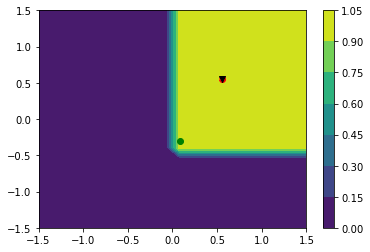

In [245]:
sigma = 1.0
alpha = 0.4
V_1 = [0.2, 0.2]
X_sim, Y_sim, X_hat_sim, V_sim = simulate(2, sigma=sigma, alpha=alpha).values()

print(Y_sim, X_sim)
def domain_lik(x_hat_1, x_hat_2):
    lik1 = likelihood(Y_sim[0], x_hat_1, V_1)
    V = update_values(V_1[0], V_1[1], X_sim[0], Y_sim[0], x_hat_1, alpha, sigma)
    lik2 = likelihood(Y_sim[1], x_hat_2, V)
    return lik1 * lik2

x_plot, y_plot = np.linspace(-1.5,1.5,20), np.linspace(-1.5,1.5,20)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
Z = []
for x in x_plot:
    for y in y_plot:
        Z.append(domain_lik(x, y))

Z = np.array(Z).reshape(len(x_plot), len(y_plot)).T

X_map_approx = approx_MAP(X_sim, Y_sim,sigma)

fig, ax = plt.subplots();
# ax.plot(x_range, [domain_lik(x, -0.2) for x in x_range])
CF = ax.contourf(X_plot, Y_plot, Z)
ax.scatter(*X_sim, c='r')
ax.scatter(*X_hat_sim, c='g')
ax.scatter(*X_map_approx, marker='+', c='tab:orange')
ax.scatter(*project_X(X_sim, Y_sim), marker='v', c='k')
fig.colorbar(CF)

## Parameter inference

In [225]:
def partial_likelihood(X, Y, X_hat, alpha, sigma):
    r'''
    For MC evaluation
    log p(y|x, x_hat, theta) = \sum
        log p(y_t | x_hat_t, V_t) + log p(x_hat_t | x_t)
    '''
    V = compute_estimated_values(X, Y, X_hat, alpha, sigma)
    emission_liks = np.array([likelihood(y, x_hat, v) for y, x_hat, v in zip(Y, X_hat, V)])
    # print(emission_liks.shape)
    latent_liks = np.array([sp.stats.norm.pdf(x_hat, loc=x, scale=sigma) for x_hat, x in zip(X_hat, X)]).flatten()
    # print(latent_liks.shape)
    return np.prod(np.prod([emission_liks, latent_liks], axis=1))

def Mstep_alpha(X, Y, sigma):
    X_hat = project_X(X, Y)
    objective_func = lambda alpha: -partial_likelihood(X,Y, X_hat, alpha, sigma=sigma)
    def constraint(alpha):
        V = compute_estimated_values(X, Y, X_hat, alpha, sigma)
        emision_liks = np.array([likelihood(y, x_hat, v) for y, x_hat, v in zip(Y, X_hat, V)])
        return float(np.all(emision_liks > 0))
    res = sp.optimize.minimize(
        objective_func, 
        x0=0.2, 
        # bounds=bounds,
        constraints={'type': 'ineq', 'fun': constraint},
        )
    print(res)
    return res.x

def Mstep_sigma(X, Y, alpha):
    X_hat = project_X(X, Y)
    
    def objective_func(sigma):
        logliks = np.array([sp.stats.norm.pdf(x_hat, loc=x, scale=sigma) for x_hat, x in zip(X_hat, X)]).flatten()
        print(logliks)
        return -np.sum(logliks)
    
    def constraint(sigma):
        V = compute_estimated_values(X, Y, X_hat, alpha, sigma)
        emision_liks = np.array([likelihood(y, x_hat, v) for y, x_hat, v in zip(Y, X_hat, V)])
        return float(np.all(emision_liks > 0))
    
    res = sp.optimize.minimize(
        objective_func, 
        x0=0.5, 
        # bounds=bounds,
        constraints={'type': 'ineq', 'fun': constraint},
        # options = {'disp':True}
        )
    print(res)
    return res.x

    

In [250]:
sigma = 1.0
alpha = 0.4
V_1 = [0.2, 0.2]
X_sim, Y_sim, X_hat_sim, V_sim = simulate(100, sigma=sigma, alpha=alpha).values()

# Mstep_alpha(X_sim, Y_sim, sigma=sigma)
# Mstep_sigma(X_sim, Y_sim, alpha=alpha)

MLE_sigma = np.sqrt(np.mean(np.square(X_sim - project_X(X_sim, Y_sim, compute_V=True, alpha=alpha, sigma=sigma))))
print(MLE_sigma)

0.9822455069944658


In [19]:
def transition_point(V, sigma):
    V_L, V_R = V
    return sigma * sp.special.erfinv((V_L-V_R)/(V_R + V_L))

def emission_likelihood(y, x_hat, V, sigma, softmax=False):
    # a = transition_point(V, sigma)
    # if softmax:
    V_L, V_R = V
    p_R = Phi(x_hat/sigma)
    p_L = 1 - p_R

    Qs = [p_L*V_L, p_R*V_R]
    if softmax:
        p = sp.special.softmax(Qs)[int(y)]
        return p
    else:
        return float(y==np.argmax(Qs))
        # if y==1:
        #     return 1. if x_hat >= a else 0.
        # else:
        #     return 1. if x_hat <= a else 0.


def bootstrap_filter(N, data, alpha, sigma, softmax=False):
    '''
    returns N samples, equally weighted, to evaluate integrals
    '''
    X, Y = data
    T = len(X)

    xhat_history = []
    V_history = []

    loglik_running_estimate = 0.

    for t in range(0,T):

        # 1. Prediction step : tilde z_t ~ p(z_t | z_{t-1})
        #   Sample proposal N particles from previous N particles
        #   {tilde z_t^i, 1/N} is an approximation to p(z_t|y_{1:t-1})
        if t==0:
            tilde_V_t = 0.2 * np.ones((N,2))
        else:
            tilde_V_t = np.array([
                update_values(_V_t[0], _V_t[1], X[t-1], Y[t-1], _xhat_t, alpha, sigma) 
                for _xhat_t, _V_t in zip(tilde_xhat_t, tilde_V_t)
                ])
        tilde_xhat_t = X[t] + sigma * np.random.randn(N)

        # 2. Evaluate importance weights p(y_t | xhat_t, V_t)
        #   {tilde z_t^i, tilde w^i} is an approximation to p(z_t|y_{1:t})
        tilde_w_t = np.array([
            emission_likelihood(y=Y[t], x_hat=_xhat, V=_V, sigma=sigma, softmax=softmax) 
            for _xhat, _V in zip(tilde_xhat_t, tilde_V_t)
            ])
        
        # Normalize
        # normalized_tilde_w_t = sp.special.softmax(tilde_w_t)
        normalized_tilde_w_t = tilde_w_t/np.sum(tilde_w_t)
        # if np.sum(tilde_w_t) == 0.:
        #     xhat_history.append(tilde_xhat_t)
        #     V_history.append(tilde_V_t)
        #     continue

        # 3. Resampling step: 
        #   Resample with replacement N particles according the importance weights
        choices = np.random.choice(N, size=N, p=normalized_tilde_w_t)
        V_t = np.array([list(tilde_V_t[c]) for c in choices])
        xhat_t = np.array([tilde_xhat_t[c] for c in choices])

        # print(np.mean([emission_likelihood(y=Y[t], x_hat=_xhat, V=_V, sigma=sigma, softmax=softmax) for _xhat, _V in zip(xhat_t, V_t)]))

        # lik_estimate = np.mean([emission_likelihood(y=Y[t], x_hat=_xhat, V=_V, sigma=sigma, softmax=softmax) for _xhat, _V in zip(xhat_t, V_t)])
        lik_estimate = np.mean(tilde_w_t)
        loglik_running_estimate += np.log(lik_estimate)

        xhat_history.append(xhat_t)
        V_history.append(V_t)

    return (xhat_history, V_history), loglik_running_estimate

100%|██████████| 5/5 [00:00<00:00,  8.43it/s]


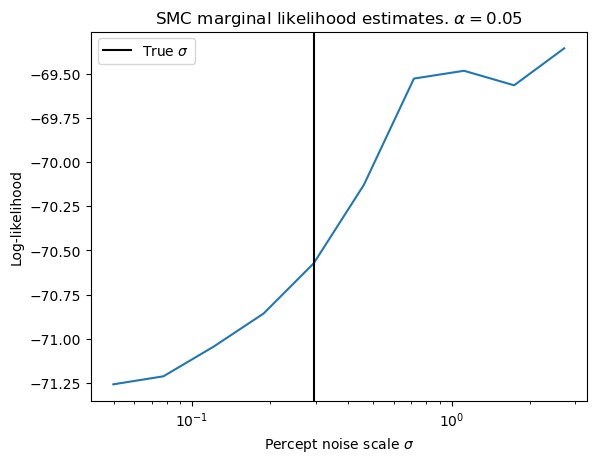

In [22]:
from scipy.optimize import curve_fit

alpha_range = np.exp(np.linspace(-5,0,10))
sigma_range = np.exp(np.linspace(-3,1,10))
true_alpha = 0.05 # alpha_range[4]
true_sigma = sigma_range[4] #0.2
use_softmax = True
T = 20
N = 50
n_trials = 5

# Define the Gaussian function
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-(x - mean)**2 / (2 * std_dev**2))

vals = []
alpha_estimates = []
for i in tqdm(range(n_trials)):
    # print('*'*(i+1))
    X, Y, _, _ = simulate(T, alpha=true_alpha, sigma=true_sigma, softmax=use_softmax)

    lik_vals = []
    # sigma_range = np.exp(np.linspace(-3,1,20))
    for sigma in sigma_range:
    # for alpha in alpha_range:
        # for sigma in sigma_range:
        # print(alpha)
        _, lik_estimate = bootstrap_filter(N, (X,Y), alpha=true_alpha, sigma=sigma, softmax=use_softmax)
        lik_vals.append(lik_estimate)

    vals.append(list(lik_vals))

    # # Estimate alpha as sum weighted by relative likelihoods
    # lik_vals=np.array(lik_vals)
    # weights=sp.special.softmax(lik_vals) #(lik_vals-np.min(lik_vals))/(np.max(lik_vals)-np.min(lik_vals))

    # # popt, _ = curve_fit(gaussian, alpha_range, lik_vals, p0=[np.max(lik_vals)-np.min(lik_vals), alpha_range[np.argmax(lik_vals)], 0.2])
    # # alpha_estimate = popt[1]
    # alpha_estimate = alpha_range[np.argmax(lik_vals)]
    # print(alpha_estimate)
    # alpha_estimates.append(alpha_estimate)


# fig, ax = plt.subplots()
# ax.plot(alpha_estimates, '.')
# ax.axhline(y=true_alpha, c='k')
# ax.set_ylim([alpha_range[0], alpha_range[-1]])
# plt.show();

vals = np.array(vals)
mean, std = np.mean(vals, axis=0), np.std(vals, axis=0)
fig, ax = plt.subplots()
ax.plot(sigma_range, np.sum(vals, axis=0))
# ax.axvline(x=true_alpha, c='k', label=r'True $\alpha$')
ax.axvline(x=true_sigma, c='k', label=r'True $\sigma$')
# ax.plot(alpha_range, vals.T, c='tab:grey')
# ax.fill_between(alpha_range, mean-std, mean+std, alpha=0.3, color='tab:blue')
ax.legend()
# ax.set_xlabel(r'Learning rate $\alpha$')
ax.set_xlabel(r'Percept noise scale $\sigma$')
ax.set_ylabel('Log-likelihood')
# ax.set_title(f'SMC marginal likelihood estimates. $\sigma=${true_sigma:1.2f}')
ax.set_title(r'SMC marginal likelihood estimates. $\alpha=$'+f'{true_alpha:1.2f}')
ax.set_xscale('log')
# plt.savefig(f'figures/alpha_inference_sigma{true_sigma}_softmax{use_softmax}_T{T}_N{N}_ntrials{n_trials}.eps', format='eps')
# plt.savefig(f'figures/sigma_inference_alpha{true_alpha}_softmax{use_softmax}_T{T}_N{N}_ntrials{n_trials}.eps', format='eps')

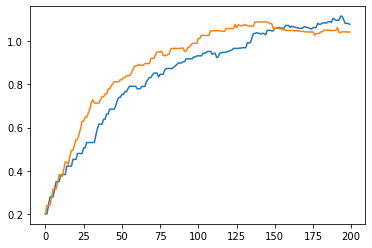

In [179]:
X, Y, X_hat,V = simulate(200, alpha=true_alpha, sigma=true_sigma, softmax=False)
plt.figure()
plt.plot(V)

In [406]:
def logpy(y, x_hat, sigma, alpha, y_prev=None, x_prev=None, x_hat_prev=None, V_prev=None):
    p_R = pR_hat(x_hat=x_hat, sigma=sigma)
    p_L = 1-p_R
    if y_prev == None:
        V = [0.2, 0.2]
    else:
        V = update_values(V_prev[0], V_prev[1], x_hat=x_hat_prev, x=x_prev, y=y_prev, alpha=alpha, sigma=sigma)
    arg = eps(y) * np.dot([-p_L, p_R], V)
    return np.log(sigmoid(arg))

def ddx_logpy(y, x_hat, sigma, alpha, y_prev=None, x_prev=None, x_hat_prev=None, V_prev=None):
    not_y = 0 if y==1 else 1
    value_difference = update_values(V_prev[0], V_prev[1], x_hat=x_hat_prev, x=x_prev, y=y_prev, alpha=alpha, sigma=sigma) - V_prev
    return logpy(not_y, x_hat, sigma, alpha, y_prev, x_prev, x_hat_prev, V_prev) * value_difference

def logpx(x_hat, x, sigma=sigma):
    return sp.stats.norm.logpdf(x_hat, loc=x, scale=sigma)

[   0.            0.58914382    0.27685458   -0.92665708   -3.0109219
   -5.96522087   -9.77859502  -14.43985638  -19.93759979  -26.26021586
  -33.39590471  -41.33269075  -50.05843828  -59.5608678   -69.82757321
  -80.84603949  -92.60366106 -105.0877605  -118.28560773 -132.1844394 ]


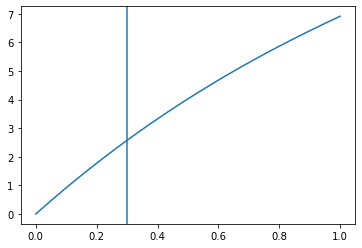

In [408]:
sigma = 0.5
alpha = 0.3
T = 10000

X, Y, X_hat, V = simulate(T=T, alpha=alpha, sigma=sigma).values()

py_vals = []
px_vals = []
dpy_vals = []
for t in range(T):
    if t == 0:
        py_alpha = lambda alpha : logpy(y=Y[t], x_hat=X_hat[t], alpha=alpha, sigma=sigma)
        dpy_alpha = lambda alpha : np.zeros(2)
    else:
        py_alpha = lambda alpha : logpy(y=Y[t], y_prev=Y[t-1], x_prev=X[t-1], x_hat=X_hat[t], x_hat_prev=X_hat[t-1], V_prev=V[t-1], alpha=alpha, sigma=sigma)
        dpy_alpha = lambda alpha: ddx_logpy(y=Y[t], y_prev=Y[t-1], x_prev=X[t-1], x_hat=X_hat[t], x_hat_prev=X_hat[t-1], V_prev=V[t-1], alpha=alpha, sigma=sigma)
    py_alphas = [py_alpha(a) for a in np.linspace(0,1,20)]
    dpy_alphas = [dpy_alpha(a) for a in np.linspace(0,1,20)]
    py_vals.append(py_alphas)
    px_vals.append(logpx(X_hat[t], X[t], sigma=sigma))
    dpy_vals.append(dpy_alphas)

print(np.sum(dpy_vals, axis=0)[:,1])
fig, ax = plt.subplots()
ax.plot(np.linspace(0,1,20), np.sum(dpy_vals, axis=0)[:,0] - np.sum(dpy_vals, axis=0)[:,1])
# ax.set_yscale('log')
# ax.plot(np.linspace(0,1,20), np.sum(py_vals, axis=0))
ax.axvline(x=alpha)
# ax.axhline(y=np.sum(px_vals))
# py_alpha2 = lambda alpha : logpy(y=Y[2], y_prev=Y[1], x_prev=X[1], x_hat=X_hat[2], x_hat_prev=X_hat[1], V_prev=V[1], alpha=alpha, sigma=sigma)
# # print(logpx(X_hat[1], X[1], sigma=sigma))
# print(logpx(X_hat[0], X[0], sigma=sigma) + logpx(X_hat[1], X[1], sigma=sigma) + logpx(X_hat[2], X[2], sigma=sigma))

# plt.figure();
# plt.plot(np.linspace(0,1,20), np.array([py_alpha0(a)+py_alpha1(a)+py_alpha2(a) for a in np.linspace(0,1,20)])); #+ np.array([py_alpha1(a) for a in np.linspace(0,1,20)]))
# # plt.plot(np.linspace(0,1,20), [py_alpha2(a) for a in np.linspace(0,1,20)])